In [2]:
import numpy as np, camb, local, importlib
from matplotlib.pyplot import *
from scipy.interpolate import RectBivariateSpline

In [3]:
importlib.reload(local)

<module 'local' from '/global/u1/t/toshiyan/Work/Ongoing/rotation/pmf-bispec/local.py'>

In [16]:
# --- CAMB calculation ---
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
lmax = 2000
pars.set_for_lmax(lmax, lens_potential_accuracy=0)
# for all ell, pars.Accuracy.lSampleBoost = 50
data = camb.get_transfer_functions(pars)
transfer = data.get_cmb_transfer_data()
# --- temperature transfer function ---
ells, ks, T_lk = transfer.get_transfer(source=0)
results = camb.get_results(pars)
eta0 = results.conformal_time(0)

In [17]:
T_spline = RectBivariateSpline(ells.astype(float),np.log(ks),T_lk,kx=3,ky=3)
def Delta_T(ell, k):
    ell = np.asarray(ell, dtype=float)
    k = np.asarray(k, dtype=float)
    if np.any(k <= 0):
        raise ValueError("k must be positive.")
    if np.any(k < ks.min()) or np.any(k > ks.max()):
        raise ValueError(f"k is outside CAMB grid: {ks.min()} <= k <= {ks.max()}")
    if np.any(ell < ells.min()) or np.any(ell > ells.max()):
        raise ValueError(f"ell is outside CAMB grid: {ells.min()} <= ell <= {ells.max()}")
    return T_spline.ev(ell, np.log(k))

In [18]:
k_arr = np.logspace(-5,-1.5,1000)

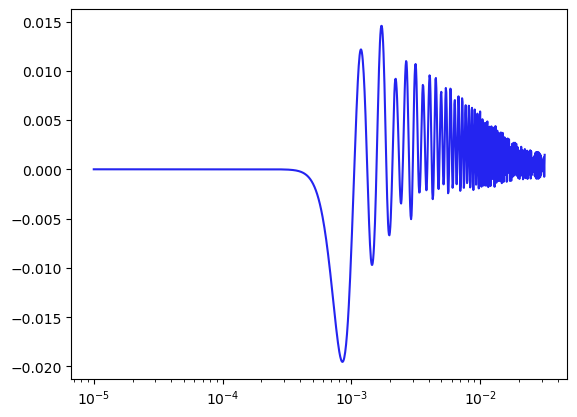

In [19]:
xscale('log')
plot(k_arr,Delta_T(10, k_arr))

In [35]:
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
pars.WantScalars = True
pars.WantTensors = True
pars.set_accuracy(AccuracyBoost=2)
data = camb.get_transfer_functions(pars)
transfer = data.get_cmb_transfer_data('tensor')
ells, ks, TB_lk = transfer.get_transfer(source=2)
TB_lk /= 4.

In [36]:
TB_spline = RectBivariateSpline(ells.astype(float),np.log(ks),TB_lk,kx=3,ky=3)
def Delta_B(ell, k):
    ell = np.asarray(ell, dtype=float)
    k = np.asarray(k, dtype=float)
    if np.any(k <= 0):
        raise ValueError("k must be positive.")
    if np.any(k < ks.min()) or np.any(k > ks.max()):
        raise ValueError(f"k is outside CAMB grid: {ks.min()} <= k <= {ks.max()}")
    if np.any(ell < ells.min()) or np.any(ell > ells.max()):
        raise ValueError(f"ell is outside CAMB grid: {ells.min()} <= ell <= {ells.max()}")
    return TB_spline.ev(ell, np.log(k))

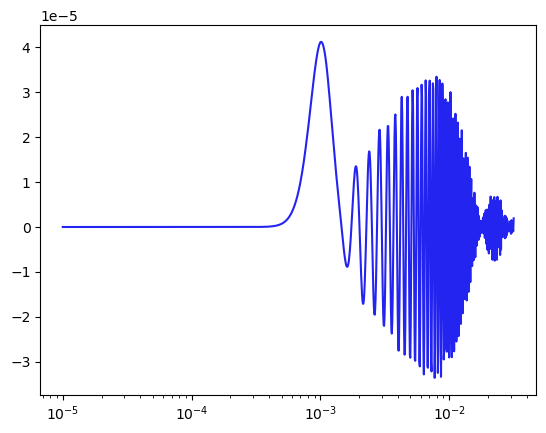

In [37]:
xscale('log')
plot(k_arr,Delta_B(10, k_arr))

In [38]:
l_list = np.linspace(0,100,101)
k = np.logspace(-5,-1.5,1000)
bb = np.zeros((101))
for ell in l_list[2:]:
    l = int(ell)
    Delta = Delta_B(l, k)
    bb[l] = np.trapezoid(Delta**2/k, k)

In [39]:
inflation_params = camb.initialpower.InitialPowerLaw()
inflation_params.set_params(ns=0.96, r=0.01)
data.power_spectra_from_transfer(inflation_params)  # warning OK here, not changing scalars
cl = data.get_tensor_cls(100, CMB_unit=None)

/tmp/ipykernel_2210232/3563503678.py:2: RuntimeWarning: invalid value encountered in divide
  loglog(np.arange(100 + 1), cl[:, 2]*2*np.pi/np.arange(100 + 1)/(np.arange(100 + 1)+1))


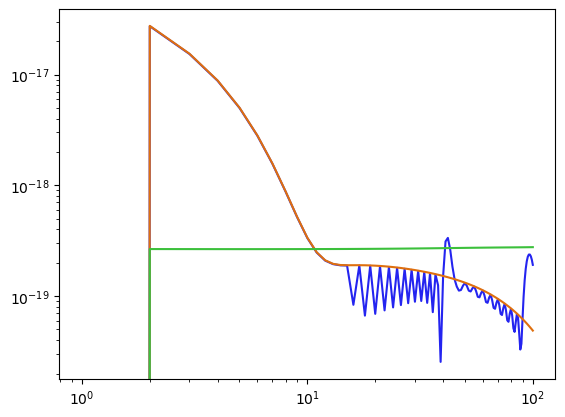

In [40]:
loglog(l_list,bb*4*np.pi*2e-9*0.01)
loglog(np.arange(100 + 1), cl[:, 2]*2*np.pi/np.arange(100 + 1)/(np.arange(100 + 1)+1))